# Differentially Private Random Forest - Kidney Stone Risk Prediction Dataset

Using IBM `diffprivlib` for DP-RF training across ε values.

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score
from diffprivlib.models import RandomForestClassifier as DPRandomForestClassifier
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
with open("../data/processed_data.pkl","rb") as f: loaded_data = pickle.load(f)
X_train=loaded_data["X_train"]; X_test=loaded_data["X_test"]
y_train=loaded_data["y_train"]; y_test=loaded_data["y_test"]
bounds=loaded_data["bounds"]
print(f"Training: {X_train.shape} | Test: {X_test.shape}")


Training: (3200, 23) | Test: (800, 23)


In [3]:
try:
    baseline_df=pd.read_csv("output/baseline_results.csv")
    baseline_accuracy=baseline_df["accuracy"].values[0]; baseline_f1=baseline_df["f1_score"].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f} | F1: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_RF.ipynb first."); baseline_accuracy=None; baseline_f1=None


Baseline Accuracy: 0.9437 | F1: 0.9236


## Single-epsilon preview (ε=1.0, 30 runs)

In [4]:
epsilon=1.0; N_RUNS=30
detail_accs=[]; detail_f1s=[]
detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed=run*10+42
    m=DPRandomForestClassifier(n_estimators=20,epsilon=epsilon,random_state=seed,n_jobs=-1,max_depth=4,bounds=bounds)
    _t0 = time.perf_counter()
    m.fit(X_train,y_train)
    train_time = time.perf_counter() - _t0
    yp=m.predict(X_test)
    detail_accs.append(accuracy_score(y_test,yp)); detail_f1s.append(f1_score(y_test,yp,zero_division=0))
    detail_extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {detail_accs[-1]:.4f} | F1: {detail_f1s[-1]:.4f}")
print(f"\nAcc: {np.mean(detail_accs):.4f}\u00b1{np.std(detail_accs):.4f} | F1: {np.mean(detail_f1s):.4f}\u00b1{np.std(detail_f1s):.4f}")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

  Run  1/30 | Acc: 0.8888 | F1: 0.8361
  Run  2/30 | Acc: 0.8900 | F1: 0.8388


  Run  3/30 | Acc: 0.8675 | F1: 0.7985


  Run  4/30 | Acc: 0.8750 | F1: 0.8127


  Run  5/30 | Acc: 0.8900 | F1: 0.8388
  Run  6/30 | Acc: 0.8788 | F1: 0.8187


  Run  7/30 | Acc: 0.8900 | F1: 0.8388


...

  Run 24/30 | Acc: 0.8825 | F1: 0.8259


  Run 25/30 | Acc: 0.8712 | F1: 0.8060
  Run 26/30 | Acc: 0.8900 | F1: 0.8388


  Run 27/30 | Acc: 0.8438 | F1: 0.7525


  Run 28/30 | Acc: 0.8700 | F1: 0.8038


  Run 29/30 | Acc: 0.8838 | F1: 0.8281
  Run 30/30 | Acc: 0.8825 | F1: 0.8259

Acc: 0.8790±0.0177 | F1: 0.8186±0.0342
Added metrics over the detail runs:
  Balanced Acc:   0.8475 ± 0.0229
  AUROC:          0.8961 ± 0.0191
  Train Time (s): 0.0253 ± 0.0056


## Full sweep across all ε values

In [5]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
N_RUNS = 30
results_json = {"model_type":"DP Random Forest","dataset":"Kidney Stone Risk Prediction Dataset","n_runs_per_epsilon":N_RUNS,"epsilon_results":{}}
results = {"epsilon":[],"accuracy_mean":[],"accuracy_std":[],"f1_score_mean":[],"f1_score_std":[],"precision_mean":[],"precision_std":[],"recall_mean":[],"recall_std":[]}
print(f"Training DP Random Forest with {N_RUNS} runs per epsilon value...")
print("="*80)
for eps in epsilon_values:
    run_accs=[]; run_f1s=[]; run_precs=[]; run_recs=[]; run_cms=[]
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        m = DPRandomForestClassifier(n_estimators=20,epsilon=eps,random_state=seed,n_jobs=-1,max_depth=4,bounds=bounds)
        _t0 = time.perf_counter()
        m.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        yp = m.predict(X_test)
        run_accs.append(accuracy_score(y_test,yp))
        extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test,yp,zero_division=0))
        run_precs.append(precision_score(y_test,yp,zero_division=0))
        run_recs.append(recall_score(y_test,yp,zero_division=0))
        run_cms.append(confusion_matrix(y_test,yp).tolist())
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(m, f'output/model/dp_rf_model_eps_{eps}.pkl')
    acc_m,acc_s=np.mean(run_accs),np.std(run_accs)
    f1_m,f1_s=np.mean(run_f1s),np.std(run_f1s)
    prec_m,prec_s=np.mean(run_precs),np.std(run_precs)
    rec_m,rec_s=np.mean(run_recs),np.std(run_recs)
    results["epsilon"].append(eps); results["accuracy_mean"].append(acc_m); results["accuracy_std"].append(acc_s)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results["f1_score_mean"].append(f1_m); results["f1_score_std"].append(f1_s)
    results["precision_mean"].append(prec_m); results["precision_std"].append(prec_s)
    results["recall_mean"].append(rec_m); results["recall_std"].append(rec_s)
    results_json["epsilon_results"][str(eps)]=dict(epsilon=float(eps),n_runs=N_RUNS,accuracy_mean=acc_m,accuracy_std=acc_s,f1_mean=f1_m,f1_std=f1_s,precision_mean=prec_m,precision_std=prec_s,recall_mean=rec_m,recall_std=rec_s,per_run_accuracies=run_accs,per_run_f1s=run_f1s,per_run_precisions=run_precs,per_run_recalls=run_recs,per_run_confusion_matrices=run_cms)
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
    print(f"\u03b5={eps:5.1f} | Acc: {acc_m:.4f}\u00b1{acc_s:.4f} | F1: {f1_m:.4f}\u00b1{f1_s:.4f} | Prec: {prec_m:.4f}\u00b1{prec_s:.4f} | Rec: {rec_m:.4f}\u00b1{rec_s:.4f}")
print("="*80); print("Training complete!")


Training DP Random Forest with 30 runs per epsilon value...


Model successfully exported to output/model/dp_rf_model_eps_0.1.pkl


ε=  0.1 | Acc: 0.8520±0.0383 | F1: 0.7641±0.0884 | Prec: 0.9852±0.0055 | Rec: 0.6315±0.1004
Model successfully exported to output/model/dp_rf_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.8719±0.0267 | F1: 0.8045±0.0555 | Prec: 0.9843±0.0042 | Rec: 0.6837±0.0703
Model successfully exported to output/model/dp_rf_model_eps_0.4.pkl


ε=  0.4 | Acc: 0.8791±0.0155 | F1: 0.8189±0.0296 | Prec: 0.9842±0.0032 | Rec: 0.7023±0.0416
Model successfully exported to output/model/dp_rf_model_eps_0.6.pkl


...

ε=  2.0 | Acc: 0.8800±0.0173 | F1: 0.8203±0.0336 | Prec: 0.9842±0.0031 | Rec: 0.7047±0.0460
Model successfully exported to output/model/dp_rf_model_eps_4.0.pkl


ε=  4.0 | Acc: 0.8802±0.0172 | F1: 0.8207±0.0334 | Prec: 0.9841±0.0031 | Rec: 0.7053±0.0459
Model successfully exported to output/model/dp_rf_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.8802±0.0172 | F1: 0.8207±0.0334 | Prec: 0.9841±0.0031 | Rec: 0.7053±0.0459
Model successfully exported to output/model/dp_rf_model_eps_8.0.pkl


ε=  8.0 | Acc: 0.8802±0.0172 | F1: 0.8207±0.0334 | Prec: 0.9841±0.0031 | Rec: 0.7053±0.0459
Model successfully exported to output/model/dp_rf_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.8802±0.0172 | F1: 0.8207±0.0334 | Prec: 0.9841±0.0031 | Rec: 0.7053±0.0459
Training complete!


In [6]:
results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df["accuracy_loss_mean"] = baseline_accuracy - results_df["accuracy_mean"]
    results_df["accuracy_loss_pct"]  = results_df["accuracy_loss_mean"] * 100
os.makedirs("output", exist_ok=True)
with open("output/dp_rf_report.json", "w") as f: json.dump(results_json, f, indent=4)
results_df.to_csv("output/dp_results.csv", index=False)
print("Results saved to output/dp_rf_report.json and output/dp_results.csv")
print(results_df.to_string(index=False))


Results saved to output/dp_rf_report.json and output/dp_results.csv
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.852042      0.038284       0.764079      0.088415        0.985247       0.005537     0.631523    0.100421                0.812647               0.049379      0.880059     0.016233         0.026254        0.006890            0.091708           9.170833
     0.2       0.871917      0.026692       0.804470      0.055525        0.984293       0.004178     0.683706    0.070307                0.838294               0.034480      0.887875     0.018117         0.023546        0.002941            0.071833           7.183333
     0.4       0.879083      0.015529       0.818912      0.029624        0.984165       0.003183     0.702343    0.041575   

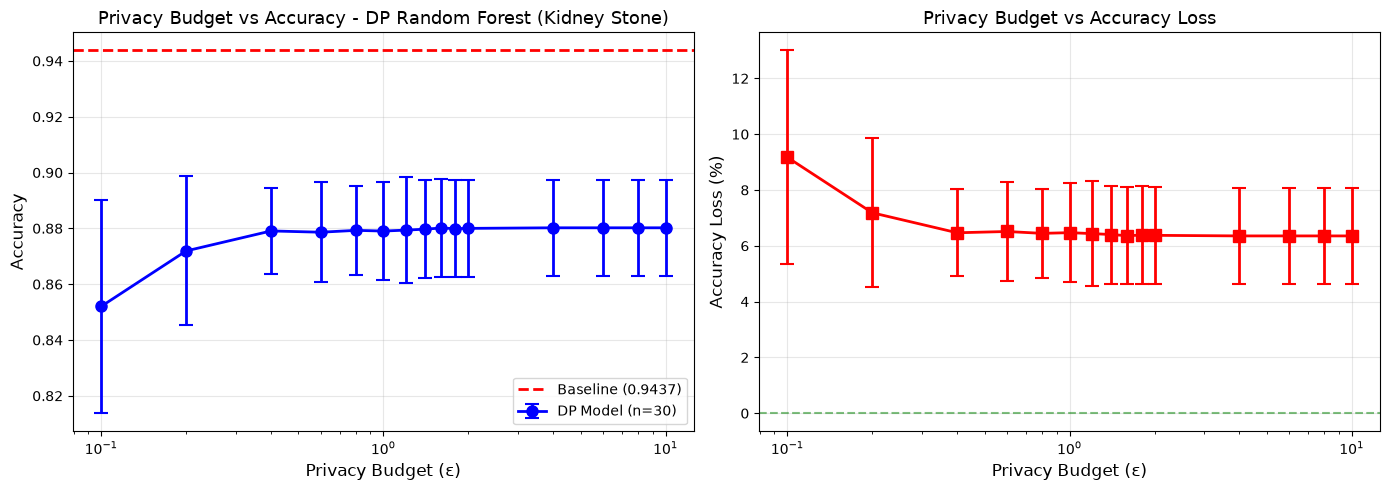

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].errorbar(results_df["epsilon"],results_df["accuracy_mean"],yerr=results_df["accuracy_std"],fmt="bo-",linewidth=2,markersize=8,capsize=5,capthick=1.5,label=f"DP Model (n={N_RUNS})")
if baseline_accuracy: axes[0].axhline(y=baseline_accuracy,color="r",linestyle="--",linewidth=2,label=f"Baseline ({baseline_accuracy:.4f})")
axes[0].set_title("Privacy Budget vs Accuracy - DP Random Forest (Kidney Stone)",fontsize=13)
axes[0].set_xlabel("Privacy Budget (\u03b5)",fontsize=12); axes[0].set_ylabel("Accuracy",fontsize=12)
axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_xscale("log")
if baseline_accuracy:
    axes[1].errorbar(results_df["epsilon"],results_df["accuracy_loss_pct"],yerr=results_df["accuracy_std"]*100,fmt="rs-",linewidth=2,markersize=8,capsize=5,capthick=1.5)
    axes[1].set_title("Privacy Budget vs Accuracy Loss",fontsize=13)
    axes[1].set_xlabel("Privacy Budget (\u03b5)",fontsize=12); axes[1].set_ylabel("Accuracy Loss (%)",fontsize=12)
    axes[1].grid(True,alpha=0.3); axes[1].set_xscale("log"); axes[1].axhline(y=0,color="g",linestyle="--",alpha=0.5)
plt.tight_layout(); plt.savefig("output/privacy_accuracy_tradeoff.png",dpi=150,bbox_inches="tight")
plt.show(); print("Plot saved.")
